# Dataset

In [ ]:
!pip install opendatasets

In [ ]:
import pandas as pd
import numpy as np
from numpy import array
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as stats
import opendatasets as od

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

from pylab import rcParams
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

In [ ]:
dataset_url = "https://www.kaggle.com/datasets/ardikasatria/datasettanamanpadisumatera/data"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: akialgrowto
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ardikasatria/datasettanamanpadisumatera


100%|██████████| 4.75k/4.75k [00:00<00:00, 5.11MB/s]

In [107]:
df = pd.read_csv('/content/datasettanamanpadisumatera/Data_Tanaman_Padi_Sumatera_version_1.csv')
df.head()

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31


In [ ]:
df.shape

(224, 7)

Total data adalah 224, di mana setiap provinsi memiliki 28 data tahunan.

Dataset ini terdiri dari atribut-atribut berikut:

Province (Provinsi): Nama provinsi.

Year (Tahun): Tahun produksi padi.

Production (Produksi): Hasil produksi atau panen tahunan (ton).

Land Area (Luas Lahan): Luas area pertanian (hektar).

Rainfall (Curah Hujan): Jumlah rata-rata curah hujan dalam setahun (milimeter).

Humidity (Kelembapan): Tingkat kelembapan rata-rata dalam setahun (persentase).

Average Temperature (Suhu Rata-rata): Rata-rata derajat suhu dalam setahun (celcius).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


# Explanatory Data Analysist (EDA)

In [ ]:
df.describe()

,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,224.000000,2.240000e+02,224.000000,224.000000,224.000000,224.000000
mean,2006.500000,1.679701e+06,374349.966920,2452.490759,80.948705,26.801964
std,8.095838,1.161387e+06,232751.161987,1031.972625,4.878680,1.197041
min,1993.000000,4.293800e+04,63142.040000,222.500000,54.200000,22.190000
25%,1999.750000,5.488570e+05,146919.500000,1703.525000,78.975000,26.177500
50%,2006.500000,1.667773e+06,373551.500000,2315.700000,82.375000,26.730000
75%,2013.250000,2.436851e+06,514570.250000,3039.700000,84.000000,27.200000
max,2020.000000,4.881089e+06,872737.000000,5522.000000,90.600000,29.850000


In [ ]:
#mengecek apakah ada nilai null

df.isnull().sum()

,0
Provinsi,0
Tahun,0
Produksi,0
Luas Panen,0
Curah hujan,0
Kelembapan,0
Suhu rata-rata,0


In [ ]:
for column in df.columns:
    print(f'--{column}--')
    display(df[column].value_counts())
    print()

--Provinsi--


,count
Provinsi,
Aceh,28
Sumatera Utara,28
Sumatera Barat,28
Riau,28
Jambi,28
Sumatera Selatan,28
Bengkulu,28
Lampung,28



--Tahun--


,count
Tahun,
1993,8
1994,8
1995,8
1996,8
1997,8
1998,8
1999,8
2000,8
2001,8



--Produksi--


...

,count
Curah hujan,
3396.0,2
2364.7,2
2584.9,2
3390.0,2
1339.0,1
...,...
2317.6,1
1825.1,1
1385.8,1



--Kelembapan--


,count
Kelembapan,
84.00,5
82.00,4
79.00,4
81.40,3
83.80,3
...,...
78.90,1
77.04,1
76.05,1



--Suhu rata-rata--


,count
Suhu rata-rata,
27.10,12
27.00,10
26.80,7
26.90,7
26.70,6
...,...
26.59,1
26.18,1
26.36,1


In [ ]:
#cek duplikasi data

df.duplicated().sum()

np.int64(0)

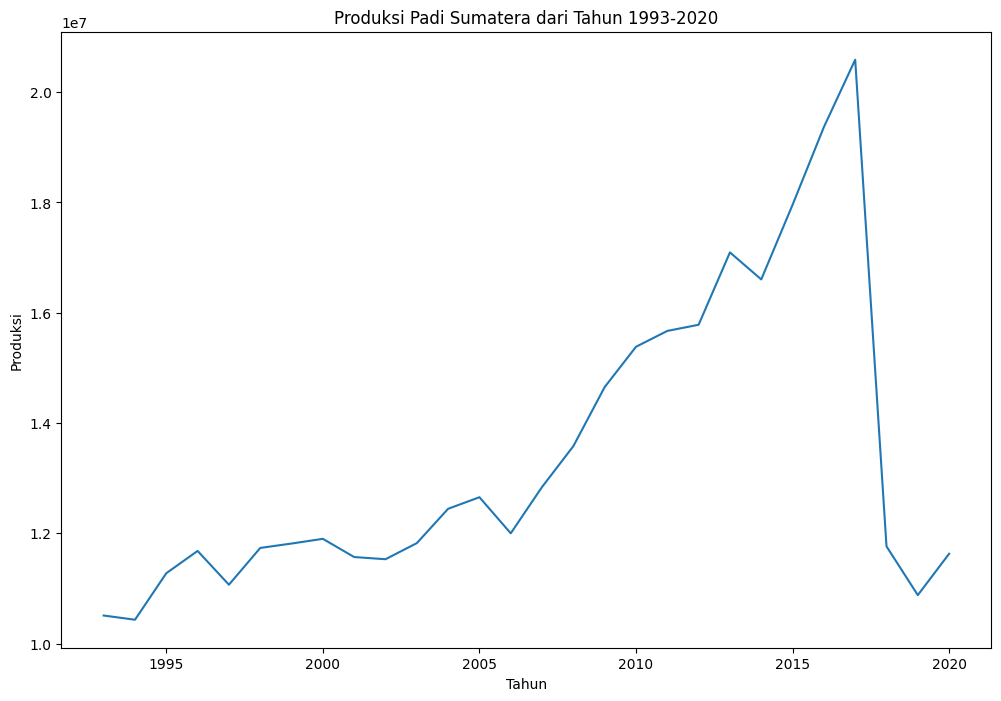

In [ ]:
plt.figure(figsize=(12,8))
df.groupby('Tahun')['Produksi'].sum().plot()
plt.xlabel('Tahun')
plt.ylabel('Produksi')
plt.title('Produksi Padi Sumatera dari Tahun 1993-2020')
plt.show()

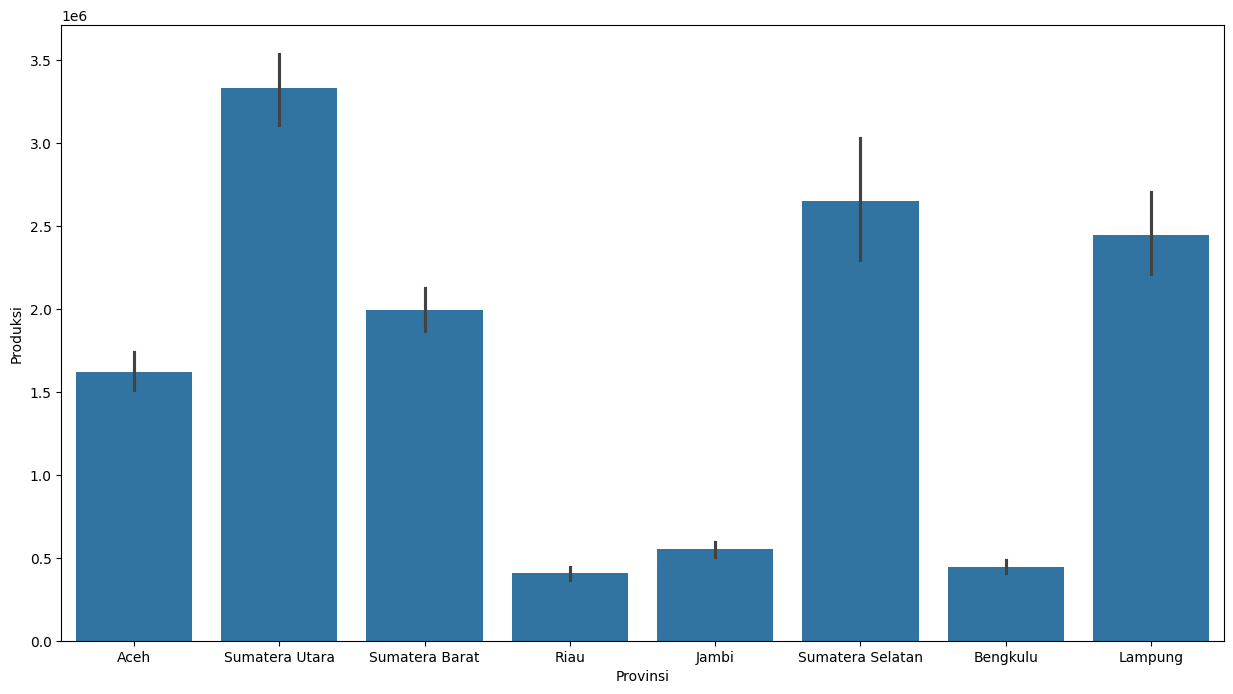

Produksi Padi per Provinsi dari Tahun 1993-2020: 
 Provinsi
Aceh                45324629.64
Bengkulu            12459015.75
Jambi               15480186.69
Lampung             68433897.53
Riau                11409006.55
Sumatera Barat      55731075.23
Sumatera Selatan    74161992.54
Sumatera Utara      93253194.72
Name: Produksi, dtype: float64


In [34]:
plt.figure(figsize=(15,8))
sns.barplot(x='Provinsi', y='Produksi', data=df)
plt.show()
print('Produksi Padi per Provinsi dari Tahun 1993-2020: \n',df.groupby('Provinsi')['Produksi'].sum())


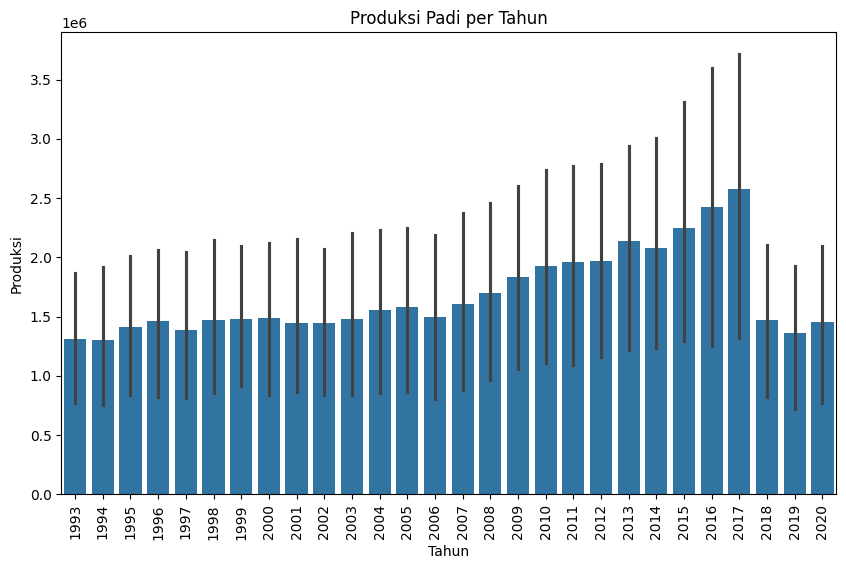

Produksi Padi per Tahun: 
 Tahun
1993    10511106.00
1994    10434879.00
1995    11277878.00
1996    11681931.00
1997    11069582.00
1998    11736390.00
1999    11816051.00
2000    11901379.00
2001    11571056.00
2002    11531731.00
2003    11823024.00
2004    12445839.00
2005    12655694.00
2006    12001280.00
2007    12841479.00
2008    13581940.00
2009    14652674.00
2010    15382976.00
2011    15670413.00
2012    15782225.00
2013    17093915.00
2014    16604009.00
2015    17956252.00
2016    19365875.90
2017    20586773.50
2018    11764423.68
2019    10881099.49
2020    11631123.08
Name: Produksi, dtype: float64


In [35]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['Tahun'],y=df['Produksi'])
plt.xlabel('Tahun')
plt.xticks(rotation=90)
plt.ylabel('Produksi')
plt.title('Produksi Padi per Tahun')
plt.show()
print('Produksi Padi per Tahun: \n',df.groupby('Tahun')['Produksi'].sum())

<Figure size 1000x600 with 0 Axes>

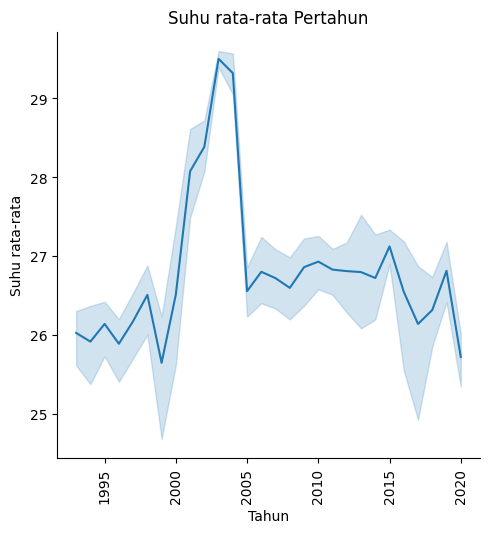

<Figure size 1000x600 with 0 Axes>

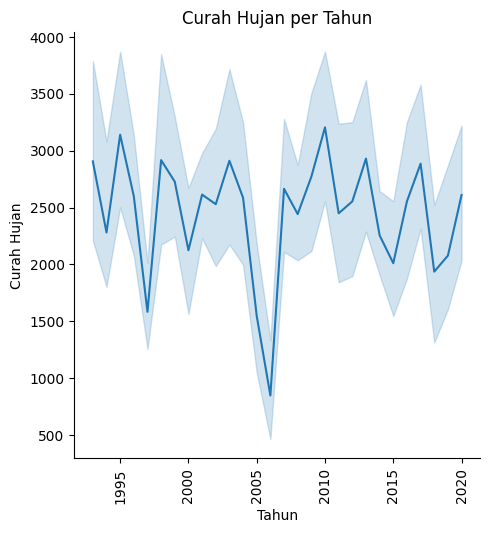

In [53]:
plt.figure(figsize=(10,6))
sns.relplot(x=df['Tahun'],y=df['Suhu rata-rata'],kind='line')
plt.xlabel('Tahun')
plt.xticks(rotation=90)
plt.ylabel('Suhu rata-rata')
plt.title('Suhu rata-rata Pertahun')
plt.show()

plt.figure(figsize=(10,6))
sns.relplot(x=df['Tahun'],y=df['Curah hujan'],kind='line')
plt.xlabel('Tahun')
plt.xticks(rotation=90)
plt.ylabel('Curah Hujan')
plt.title('Curah Hujan per Tahun')
plt.show()

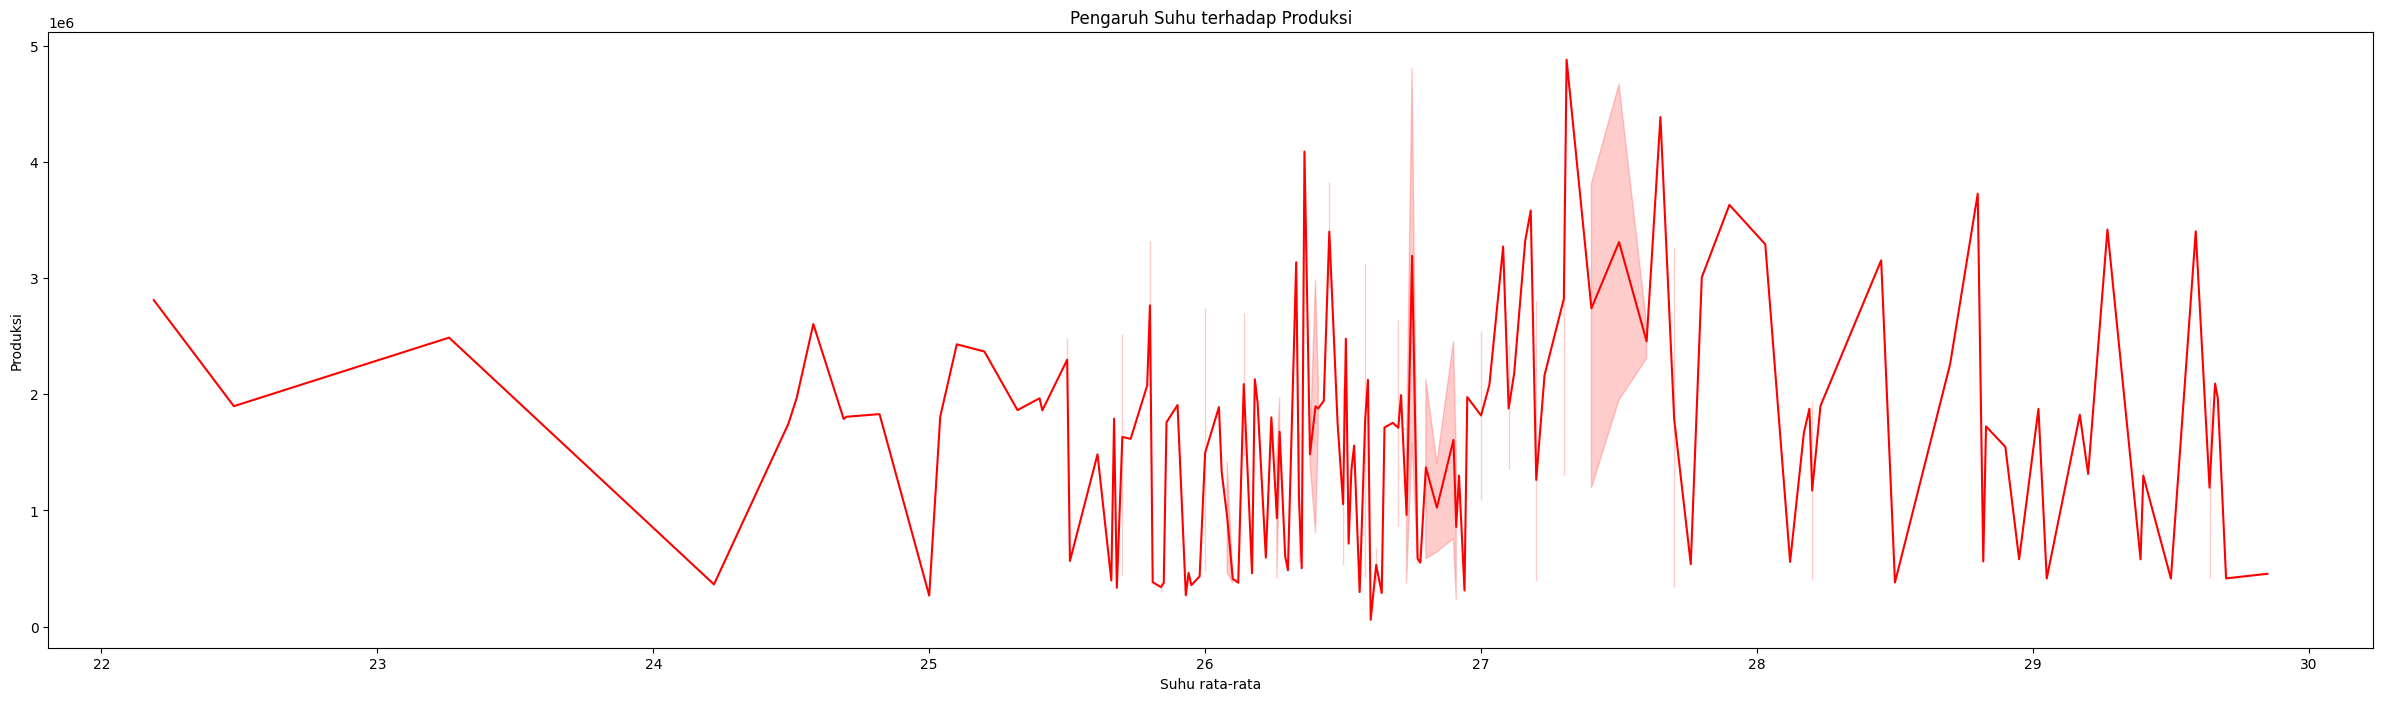

In [72]:
plt.figure(figsize=(30,8))
sns.lineplot(x='Suhu rata-rata', y='Produksi', data=df, color='red')
plt.title('Pengaruh Suhu terhadap Produksi')
plt.show()


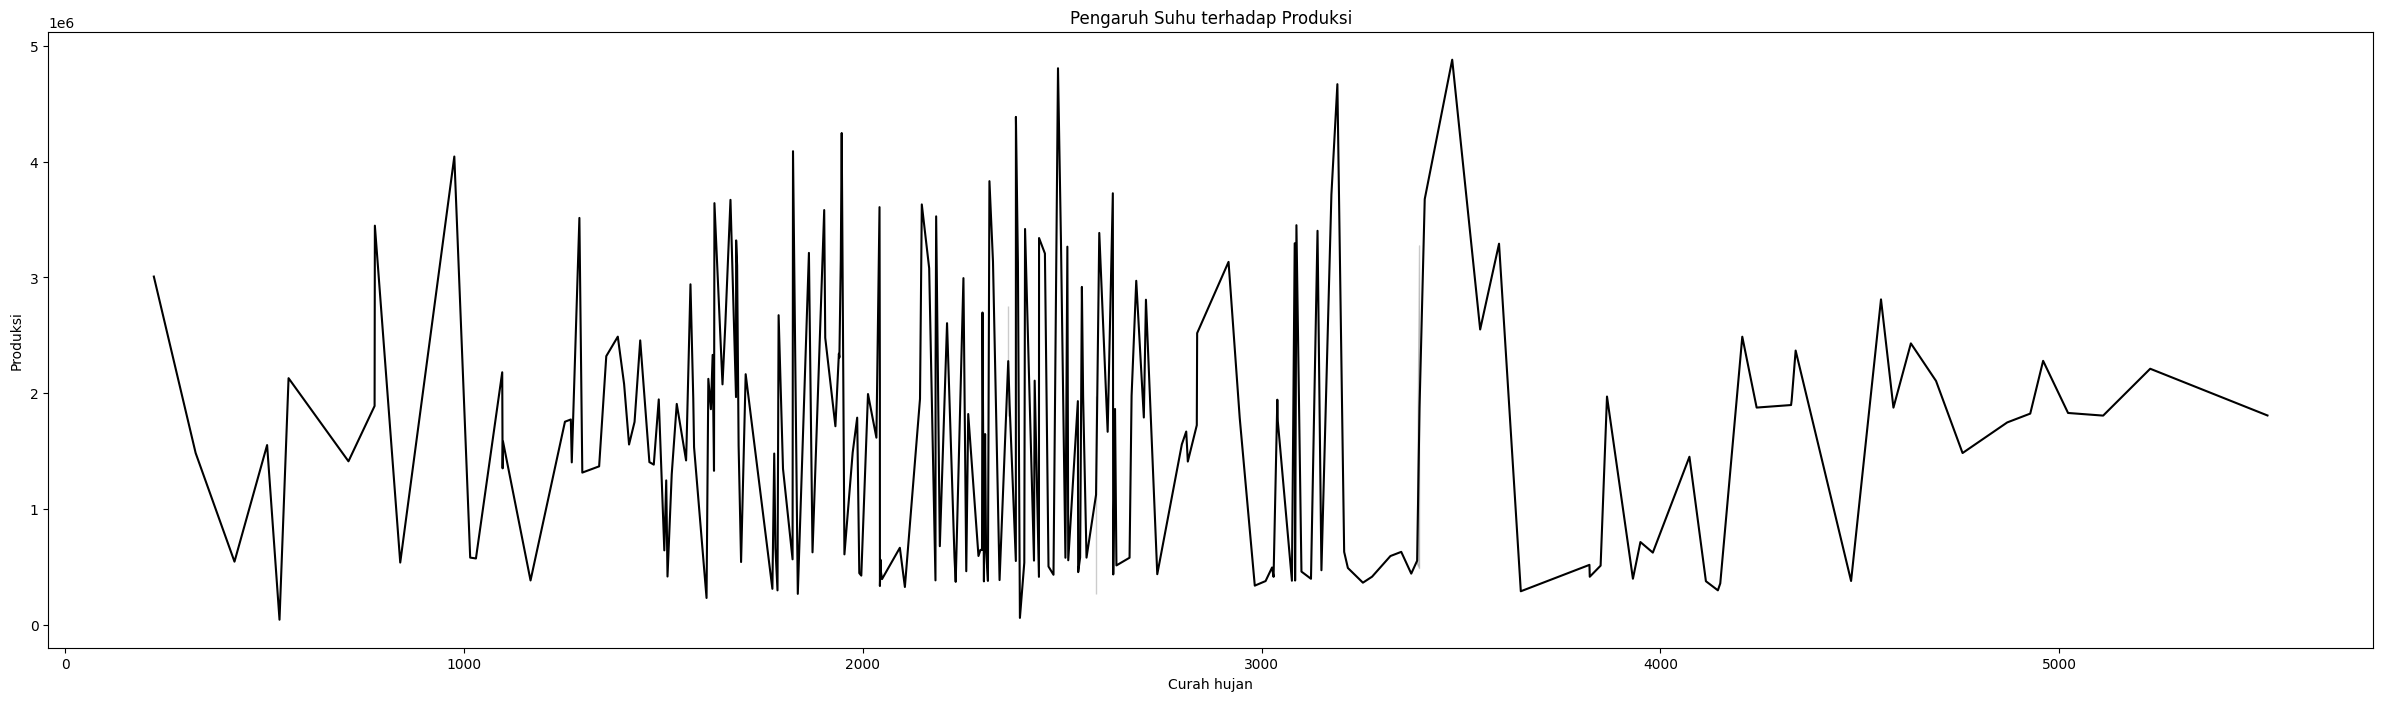

In [54]:
plt.figure(figsize=(30,8))
sns.lineplot(x='Curah hujan', y='Produksi', data=df, color='black')
plt.title('Pengaruh Suhu terhadap Produksi')
plt.show()

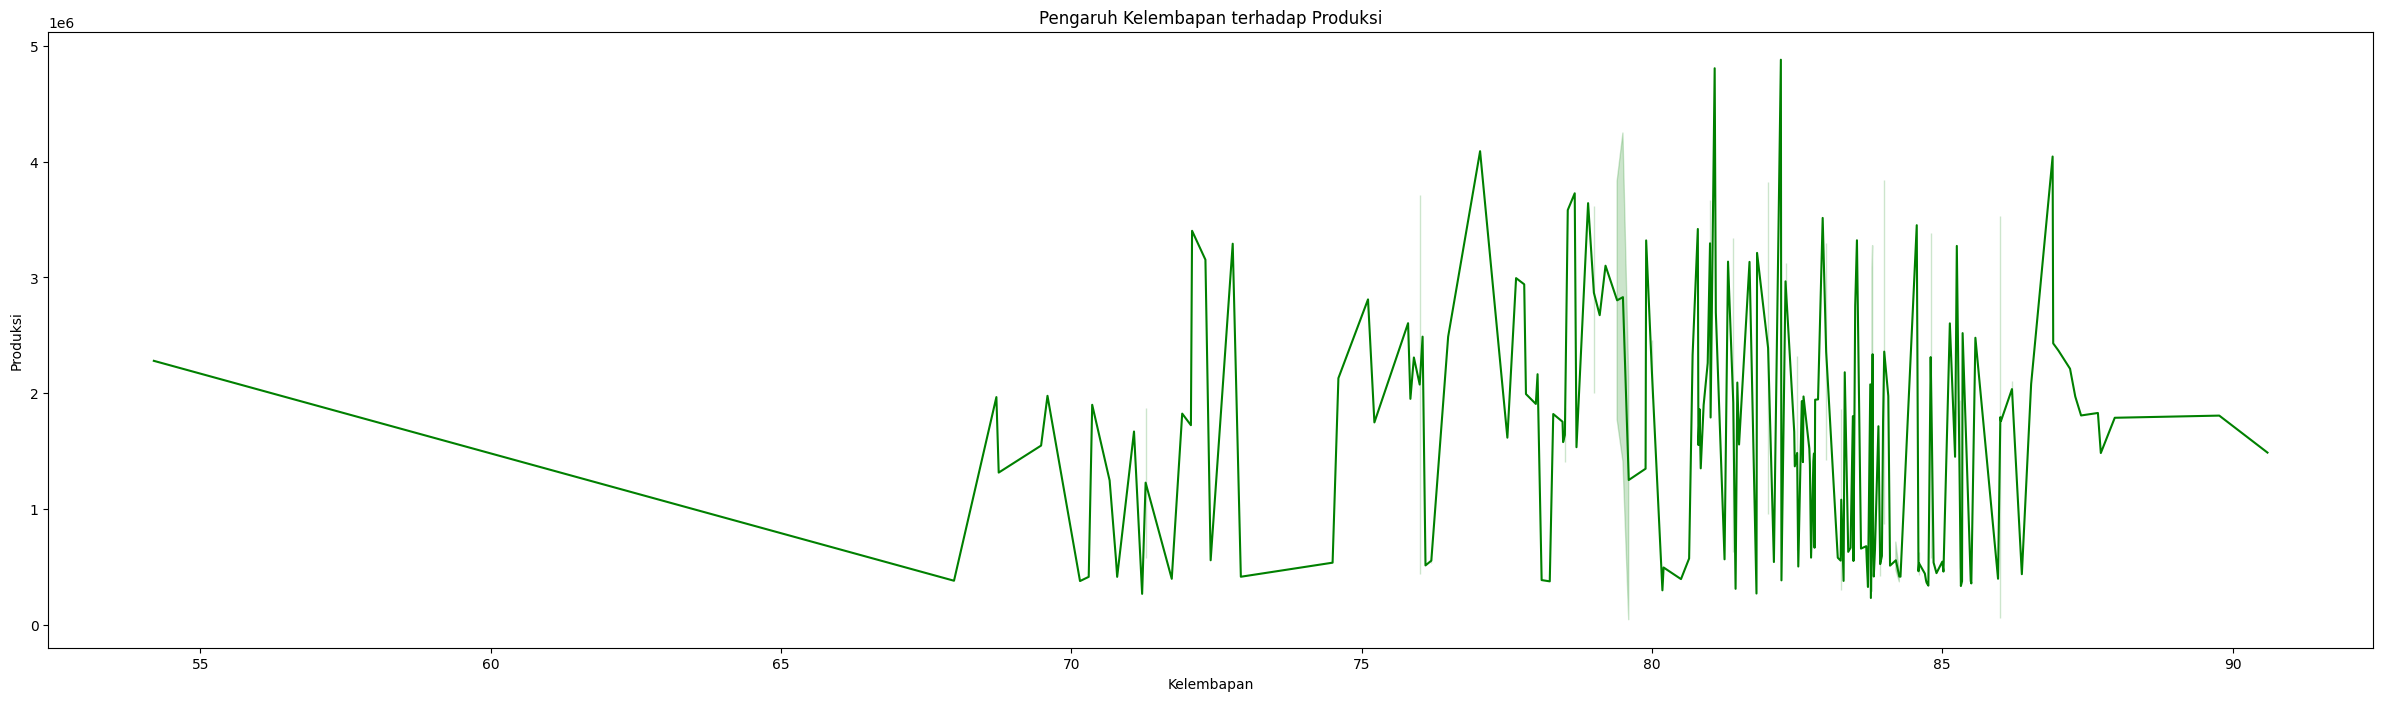

In [49]:
plt.figure(figsize=(30,8))
sns.lineplot(x='Kelembapan', y='Produksi', data=df, color='Green')
plt.title('Pengaruh Kelembapan terhadap Produksi')
plt.show()

<Figure size 1000x600 with 0 Axes>

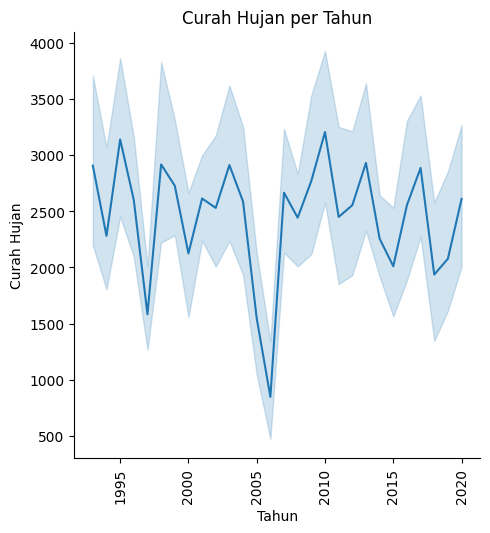

In [52]:
plt.figure(figsize=(10,6))
sns.relplot(x=df['Tahun'],y=df['Curah hujan'],kind='line')
plt.xlabel('Tahun')
plt.xticks(rotation=90)
plt.ylabel('Curah Hujan')
plt.title('Curah Hujan per Tahun')
plt.show()

Cek distribusi data

In [56]:
import scipy.stats as stats
import pylab as py

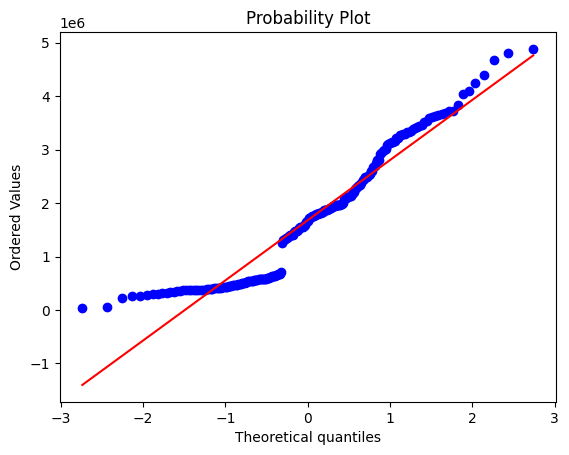

In [58]:
#QQ-plot (Quantile-Quantile Plot)
stats.probplot(df['Produksi'], dist='norm', plot=py)
py.show()

Cek Outlier dari data

<Axes: >

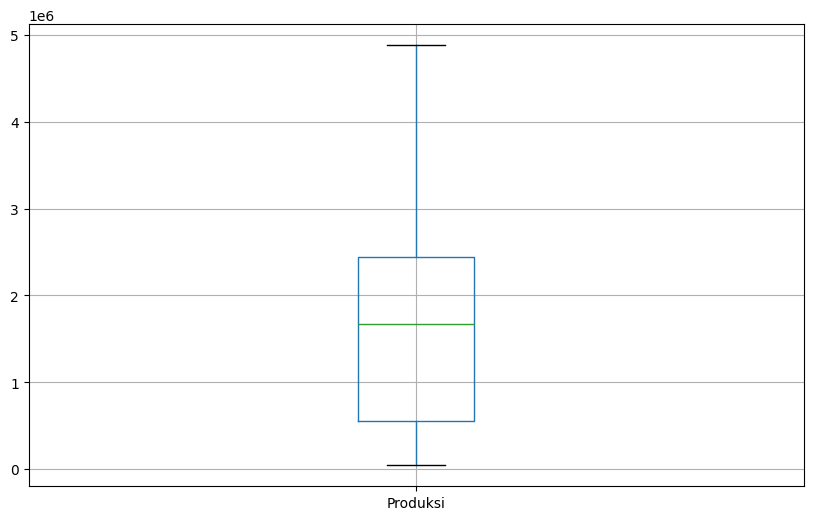

In [59]:
df[['Produksi']].boxplot(figsize=(10,6))

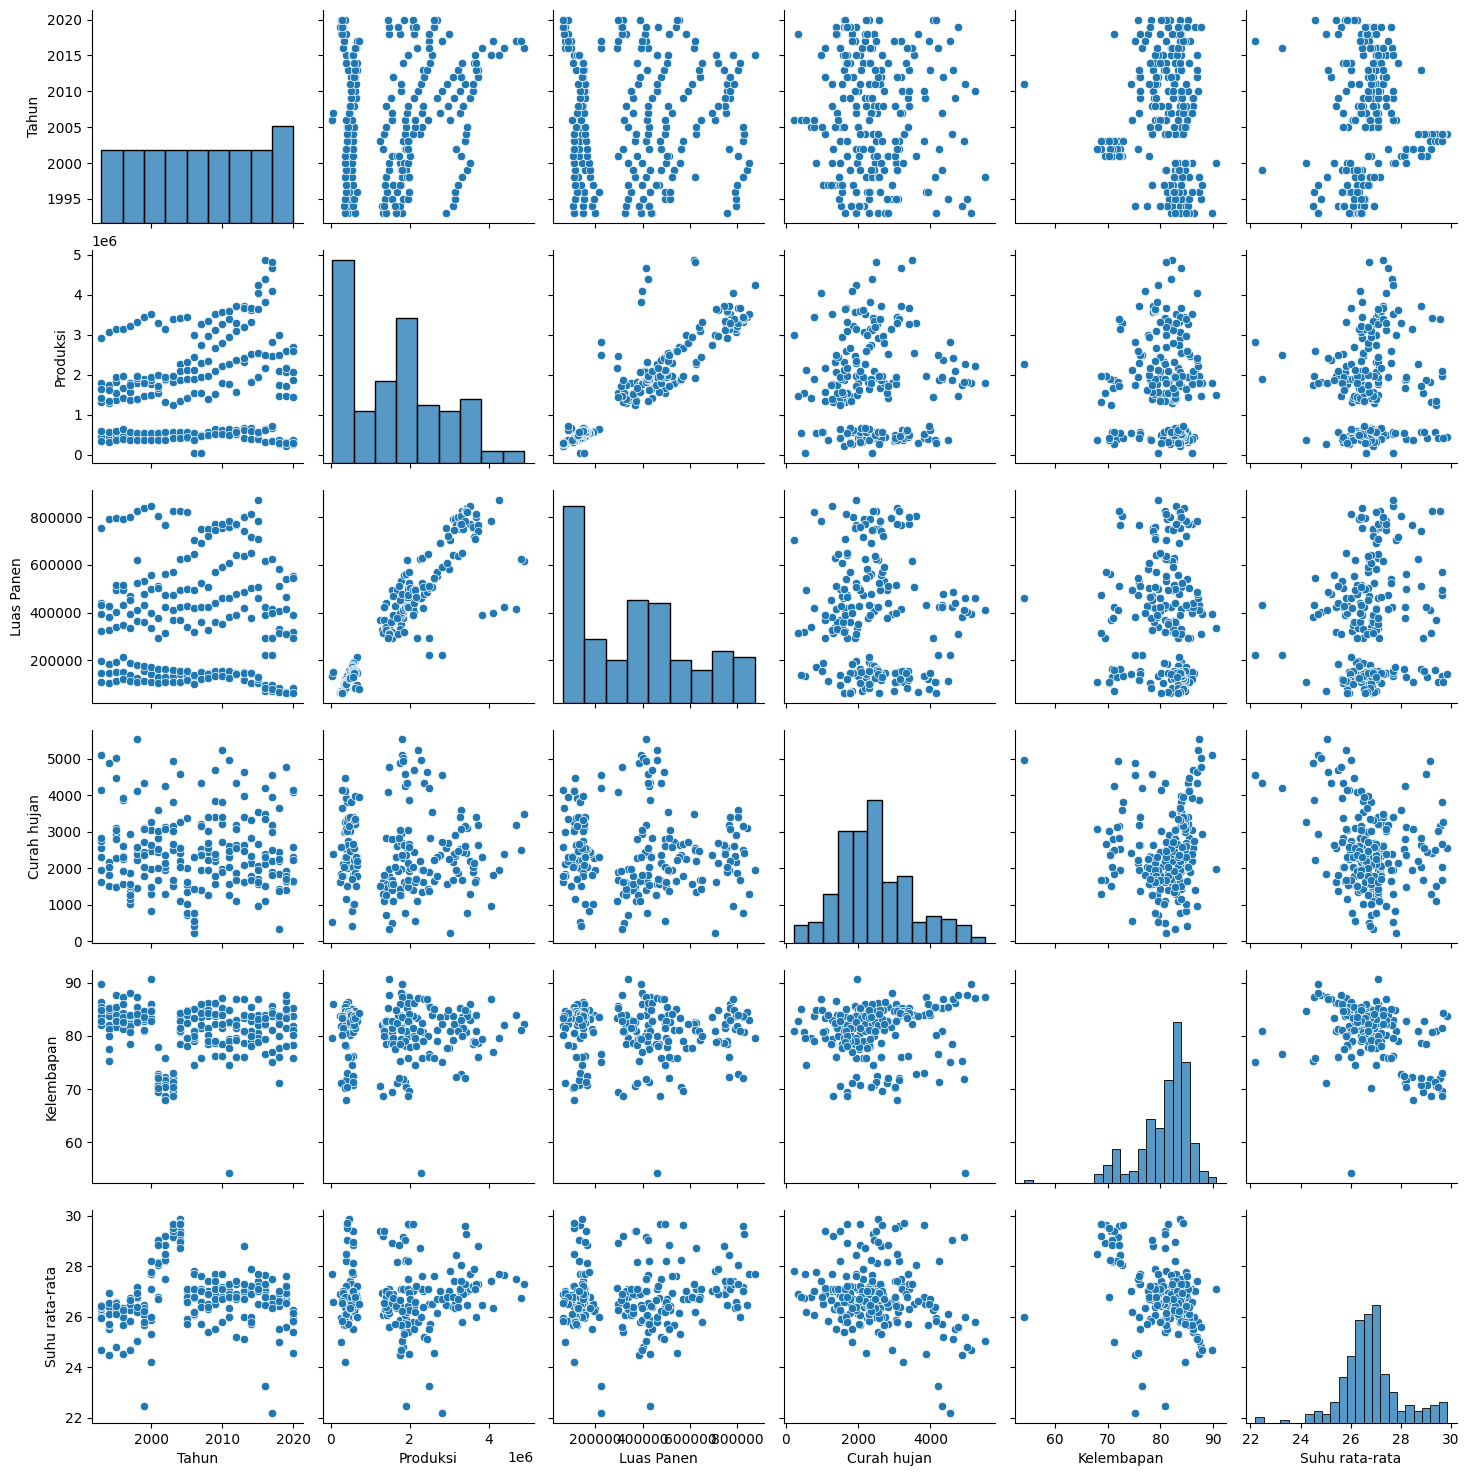

In [60]:
sns.pairplot(df)

Cek Korelasi di antara variabel numerik

In [108]:
df.columns

Index(['Provinsi', 'Tahun', 'Produksi', 'Luas Panen', 'Curah hujan',
       'Kelembapan', 'Suhu rata-rata'],
      dtype='object')

In [109]:
#melakukan perubahan pada data keseluruhan kolom
#gampangnya memindahkan kolom produksi di akhir
kolom = list(df.columns)
df2 = df.copy()
df2 = df[kolom[1:2] + kolom[3:7] + [kolom[2]]]
df2.tail()

,Tahun,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Produksi
219,2016,390799.00,2317.6,79.40,26.45,3831923.00
220,2017,396559.00,1825.1,77.04,26.36,4090654.00
221,2018,511940.93,1385.8,76.05,25.50,2488641.91
222,2019,464103.42,1706.4,78.03,27.23,2164089.33
223,2020,545149.05,2211.3,75.80,24.58,2604913.29


In [110]:
df2.corr()

,Tahun,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Produksi
Tahun,1.000000,-0.045951,-0.047645,-0.033474,0.004923,0.182527
Luas Panen,-0.045951,1.000000,-0.092975,-0.061121,0.115726,0.905622
Curah hujan,-0.047645,-0.092975,1.000000,0.056466,-0.228699,-0.042129
Kelembapan,-0.033474,-0.061121,0.056466,1.000000,-0.407799,-0.052316
Suhu rata-rata,0.004923,0.115726,-0.228699,-0.407799,1.000000,0.041160
Produksi,0.182527,0.905622,-0.042129,-0.052316,0.041160,1.000000


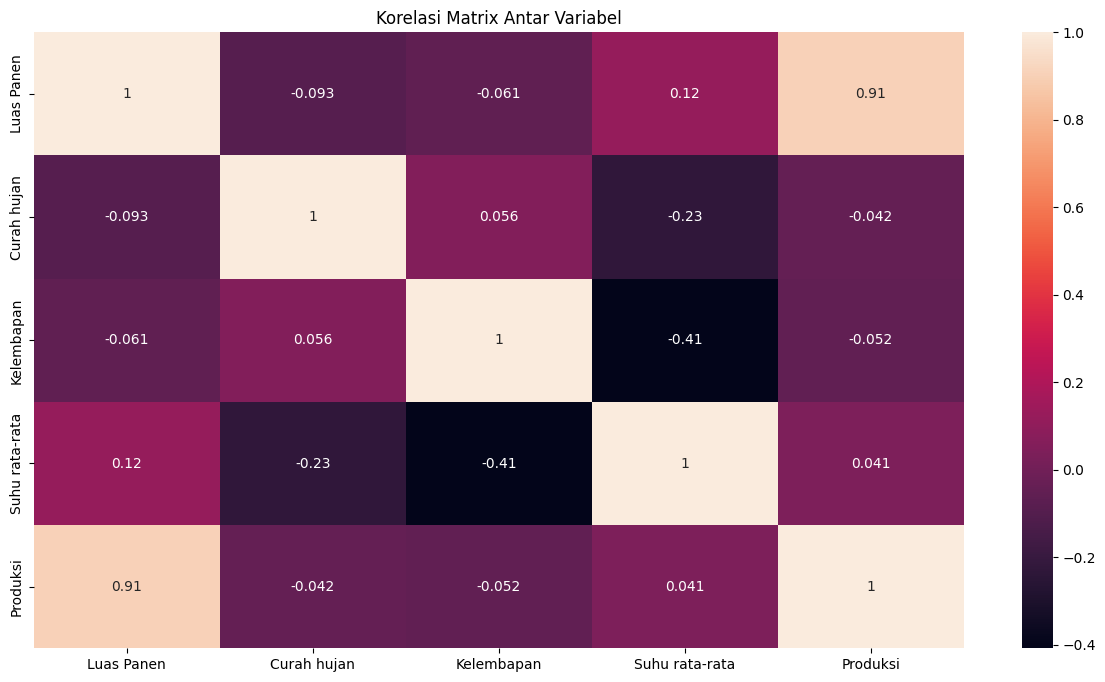

In [111]:
fig, ax = plt.subplots(figsize=(15,8), dpi=100)
sns.heatmap(df2.loc[:,'Luas Panen':'Produksi'].corr(),annot=True)
plt.title('Korelasi Matrix Antar Variabel')
plt.show()

# Data Preprocessing

Feature Enginering

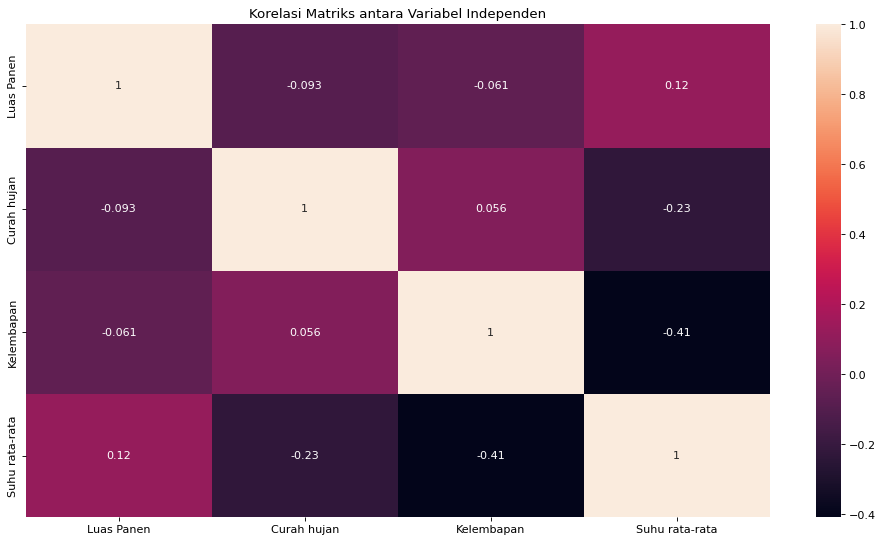

In [112]:
#checking multicollinearity
fig, ax = plt.subplots(figsize=(15,8), dpi=80)
sns.heatmap(df2.loc[:, 'Luas Panen':'Suhu rata-rata'].corr(), cmap='rocket', annot=True)
plt.title('Korelasi Matriks antara Variabel Independen')
plt.show()

In [115]:
kolom = list(df.columns)
df3 = df.copy()
df3 = df[kolom[0:2] + kolom[3:7] + [kolom[2]]]
df3.tail()

,Provinsi,Tahun,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Produksi
219,Lampung,2016,390799.00,2317.6,79.40,26.45,3831923.00
220,Lampung,2017,396559.00,1825.1,77.04,26.36,4090654.00
221,Lampung,2018,511940.93,1385.8,76.05,25.50,2488641.91
222,Lampung,2019,464103.42,1706.4,78.03,27.23,2164089.33
223,Lampung,2020,545149.05,2211.3,75.80,24.58,2604913.29


Feature Selection

In [116]:
df3 = df3.drop(columns='Tahun')
df3.tail()

,Provinsi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Produksi
219,Lampung,390799.00,2317.6,79.40,26.45,3831923.00
220,Lampung,396559.00,1825.1,77.04,26.36,4090654.00
221,Lampung,511940.93,1385.8,76.05,25.50,2488641.91
222,Lampung,464103.42,1706.4,78.03,27.23,2164089.33
223,Lampung,545149.05,2211.3,75.80,24.58,2604913.29


In [117]:
#melakukan Label Encoding pada kolom data Provinsi
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
df3['Provinsi'] = le.fit_transform(df3['Provinsi'])
df3.sample(5)

,Provinsi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Produksi
201,3,521575.0,2584.9,84.07,26.95,1975700.0
142,6,492448.0,2800.0,82.71,26.54,1557944.0
2,0,339253.0,1476.0,82.72,26.27,1382905.0
102,4,145242.0,2405.0,74.50,27.00,535788.0
61,5,412810.0,5522.0,87.39,25.04,1807622.0


In [126]:
#kolom produksi dari data fitur menjadi data target
x = df3.drop('Produksi',axis=1)
y = df3[['Produksi']]

In [264]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=0)
print('x_train :',x_train.shape)
print('x_test :',x_test.shape)
print('y_train :',y_train.shape)
print('y_test :',y_test.shape)

x_train : (156, 5)
x_test : (68, 5)
y_train : (156, 1)
y_test : (68, 1)


In [188]:
# Melakukan transformasi data dengan menggunakan StandardScaler
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.fit_transform(x_test)
y_train_scaled = sc.fit_transform(y_train)
y_test_scaled = sc.fit_transform(y_test)

In [189]:
x_train[:5]

,Provinsi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
166,6,539316.52,1655.5,85.13,27.60
40,7,822073.00,776.7,83.80,27.00
13,0,320789.00,506.5,80.80,26.73
122,2,159463.00,2508.1,71.28,29.39
89,4,126280.00,2233.0,84.26,26.73


In [190]:
print(x_train_scaled[:5])
print(y_train_scaled[:5])

[[ 1.07102820e+00  7.16699915e-01 -8.39566916e-01  9.37541781e-01
   6.92312495e-01]
 [ 1.50276049e+00  1.92735709e+00 -1.70505807e+00  6.36262189e-01
   2.09231762e-01]
 [-1.51936558e+00 -2.18952945e-01 -1.97116607e+00 -4.33158388e-02
  -8.15456793e-03]
 [-6.55900989e-01 -9.09690355e-01  1.21023610e-04 -2.19984345e+00
   2.13350335e+00]
 [ 2.07563604e-01 -1.05176751e+00 -2.70812770e-01  7.40464153e-01
  -8.15456793e-03]]
[[ 0.77273334]
 [ 1.48736091]
 [-0.11743608]
 [-0.94191188]
 [-1.11821706]]


In [191]:
print(y_train_scaled[:5])
print(y_test_scaled[:5])

[[ 0.77273334]
 [ 1.48736091]
 [-0.11743608]
 [-0.94191188]
 [-1.11821706]]
[[-1.11263695]
 [ 0.26419173]
 [-1.19391204]
 [-0.88288197]
 [-1.07069477]]


In [192]:
print(x_train_scaled.min())
print(x_train_scaled.max())

-3.6634654470384587
2.678829945386355


# Modeling

In [193]:
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

## Linear Regression

Regresi Linear adalah sebuah algoritma untuk pemodelan regresi yang digunakan untuk memprediksi nilai suatu variabel berdasarkan nilai dari variabel-variabel lainnya.

In [267]:
# Modelling with Linear regression
from sklearn.linear_model import LinearRegression

# Melakukan pemodelan regresi linear
linreg = LinearRegression()
linreg.fit(x_train_scaled, y_train_scaled)

LinearRegression()

In [270]:
# Prediksi hasil model regresi linear
y_pred_linear = linreg.predict(x_test_scaled)

# Melihat skor hasil model regresi linear
linreg.score(x_test_scaled, y_test_scaled)

0.8459084031813329

In [271]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Mean Squared Error
print('Mean Squared Error Linear Regression : ', mean_squared_error(y_test_scaled, y_pred_linear))
# Mean Absolute Error
print('Mean Absolute Error Linear Regression : ', mean_absolute_error(y_test_scaled, y_pred_linear))
# Root Mean Squared Error
print('Root Mean Squared Error Linear Regression : ', math.sqrt(mean_squared_error(y_test_scaled, y_pred_linear)))
# Coefficients of Determination (R2-Squared)
print('R2-Squared Linear Regression : ', r2_score(y_test_scaled, y_pred_linear))

Mean Squared Error Linear Regression :  0.15409159681866708
Mean Absolute Error Linear Regression :  0.21161180793746093
Root Mean Squared Error Linear Regression :  0.39254502521197115
R2-Squared Linear Regression :  0.8459084031813329


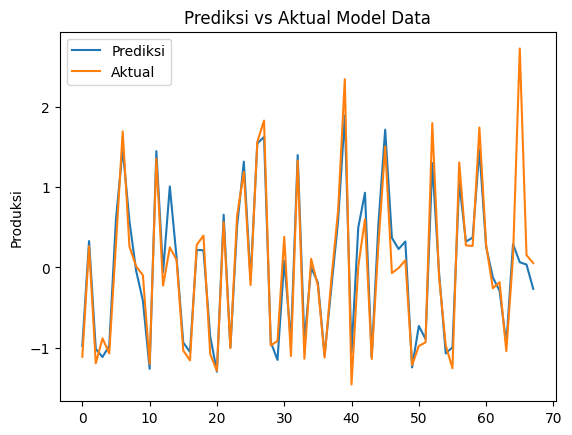

In [272]:
# Hasil Prediksi dengan Aktual Data Model Regresi Linear
plt.plot(y_pred_linear)
plt.plot(y_test_scaled)
plt.title('Prediksi vs Aktual Model Data')
plt.ylabel("Produksi")
plt.legend(labels=['Prediksi', 'Aktual'], loc='upper left')

## Random Forest Regression

In [273]:
# Modelling with Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [274]:
# Prediksi
y_pred_rf = rf.predict(x_test_scaled)

# Skor model
rf.score(x_test_scaled, y_test_scaled)

0.8628153335476698

In [275]:
# Mean Squared Error
print('Mean Squared Error Random Forest : ', mean_squared_error(y_test_scaled, y_pred_rf))

# Mean Absolute Error
print('Mean Absolute Error Random Forest : ', mean_absolute_error(y_test_scaled, y_pred_rf))

# Root Mean Squared Error
print('Root Mean Squared Error Random Forest : ', math.sqrt(mean_squared_error(y_test_scaled, y_pred_rf)))

# R2 Score
print('R2-Squared Random Forest : ', r2_score(y_test_scaled, y_pred_rf))

Mean Squared Error Random Forest :  0.13718466645233024
Mean Absolute Error Random Forest :  0.2109896520044173
Root Mean Squared Error Random Forest :  0.3703844846268945
R2-Squared Random Forest :  0.8628153335476698


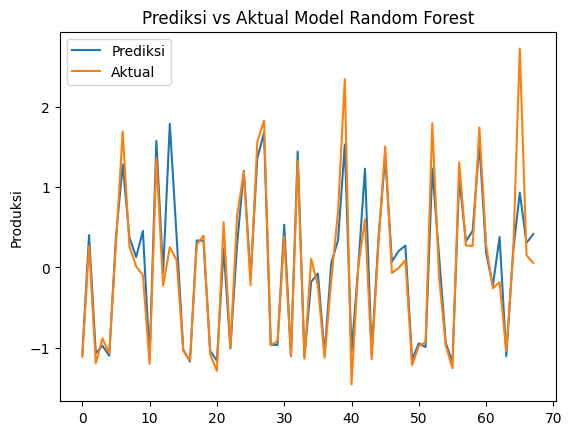

In [276]:
# Visualisasi Prediksi vs Aktual
plt.plot(y_pred_rf)
plt.plot(y_test_scaled)
plt.title('Prediksi vs Aktual Model Random Forest')
plt.ylabel("Produksi")
plt.legend(labels=['Prediksi', 'Aktual'], loc='upper left')

## Decision Tree Regression

In [277]:
# Modelling with Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)

#training model
dt.fit(x_train_scaled, y_train_scaled)


DecisionTreeRegressor(random_state=42)

In [278]:
# Prediksi
y_pred_dt = dt.predict(x_test_scaled)

# Skor model
dt.score(x_test_scaled, y_test_scaled)

0.7905948539049578

In [279]:
# Mean Squared Error
print('Mean Squared Error Decision Tree : ', mean_squared_error(y_test_scaled, y_pred_dt))

# Mean Absolute Error
print('Mean Absolute Error Decision Tree : ', mean_absolute_error(y_test_scaled, y_pred_dt))

# Root Mean Squared Error
print('Root Mean Squared Error Decision Tree : ', math.sqrt(mean_squared_error(y_test_scaled, y_pred_dt)))

# R2 Score
print('R2-Squared Decision Tree : ', r2_score(y_test_scaled, y_pred_dt))

Mean Squared Error Decision Tree :  0.20940514609504224
Mean Absolute Error Decision Tree :  0.26763061497062174
Root Mean Squared Error Decision Tree :  0.4576080703998152
R2-Squared Decision Tree :  0.7905948539049578


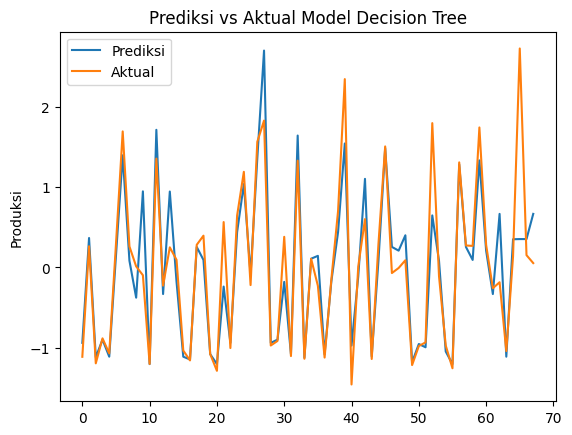

In [280]:
# Visualisasi Prediksi vs Aktual
plt.plot(y_pred_dt)
plt.plot(y_test_scaled)
plt.title('Prediksi vs Aktual Model Decision Tree')
plt.ylabel("Produksi")
plt.legend(labels=['Prediksi', 'Aktual'], loc='upper left')

## K-Neighbors Regression

In [281]:
# Modelling with K-Nearest Neighbors
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)

#training model
knn.fit(x_train_scaled, y_train_scaled)

KNeighborsRegressor()

In [282]:
# Prediksi
y_pred_knn = knn.predict(x_test_scaled)

# Skor model
knn.score(x_test_scaled, y_test_scaled)

0.8235377196313831

In [283]:
# Mean Squared Error
print('Mean Squared Error KNN : ', mean_squared_error(y_test_scaled, y_pred_knn))

# Mean Absolute Error
print('Mean Absolute Error KNN : ', mean_absolute_error(y_test_scaled, y_pred_knn))

# Root Mean Squared Error
print('Root Mean Squared Error KNN : ', math.sqrt(mean_squared_error(y_test_scaled, y_pred_knn)))

# R2 Score
print('R2-Squared KNN : ', r2_score(y_test_scaled, y_pred_knn))

Mean Squared Error KNN :  0.17646228036861694
Mean Absolute Error KNN :  0.29468592299905455
Root Mean Squared Error KNN :  0.42007413675280814
R2-Squared KNN :  0.8235377196313831


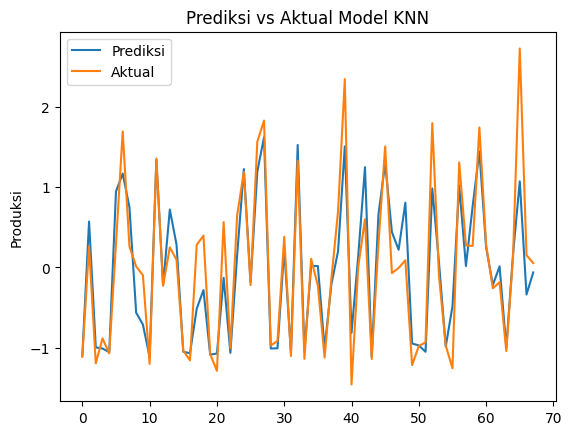

In [284]:
# Visualisasi Prediksi vs Aktual
plt.plot(y_pred_knn)
plt.plot(y_test_scaled)
plt.title('Prediksi vs Aktual Model KNN')
plt.ylabel("Produksi")
plt.legend(labels=['Prediksi', 'Aktual'], loc='upper left')

# Model Evaluation

Berikut adalah terjemahan penjelasan metrik evaluasi tersebut ke dalam bahasa Indonesia untuk laporan atau notebook kamu:

Evaluasi di bawah ini dilakukan menggunakan Mean Absolute Error (MAE), Mean Squared Error (MSE), dan R2-score. Semakin kecil nilai MAE dan MSE, namun semakin besar nilai R2-score, maka semakin baik performa algoritma tersebut.

R2-score (Koefisien Determinasi): Fungsi skor regresi ini merepresentasikan proporsi variansi dari item (hasil panen) dalam model regresi. R2-score menunjukkan seberapa baik titik-titik data cocok dengan kurva atau garis regresi.

Mean Absolute Error (MAE): Merepresentasikan rata-rata selisih absolut antara nilai aktual (asli) dan nilai prediksi dalam dataset. MAE mengukur rata-rata dari residu (kesalahan) dalam dataset.

Mean Squared Error (MSE): Merepresentasikan rata-rata dari selisih kuadrat antara nilai asli dan nilai prediksi dalam dataset. MSE mengukur variansi dari residu tersebut.

In [241]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [290]:
#inisialisasi dataframe
results = pd.DataFrame(columns=['R2-score','Mean Absolute Error','Mean Squared Error'])

# 1. Linear Regression
results.loc['Linear Regression'] = [
    r2_score(y_test_scaled, y_pred_linear)*100,
    mean_absolute_error(y_test_scaled, y_pred_linear),
    mean_squared_error(y_test_scaled, y_pred_linear)
]

# 2. Random Forest
results.loc['Random Forest'] = [
    r2_score(y_test_scaled, y_pred_rf)*100,
    mean_absolute_error(y_test_scaled, y_pred_rf),
    mean_squared_error(y_test_scaled, y_pred_rf)
]

# 3. K-Neighbors
results.loc['K-Neighbors'] = [
    r2_score(y_test_scaled, y_pred_knn)*100,
    mean_absolute_error(y_test_scaled, y_pred_knn),
    mean_squared_error(y_test_scaled, y_pred_knn)
]

# 4. Decision Tree
results.loc['Decision Tree'] = [
    r2_score(y_test_scaled, y_pred_dt)*100,
    mean_absolute_error(y_test_scaled, y_pred_dt),
    mean_squared_error(y_test_scaled, y_pred_dt)
]

results

,R2-score,Mean Absolute Error,Mean Squared Error
Linear Regression,84.590840,0.211612,0.154092
Random Forest,86.281533,0.210990,0.137185
K-Neighbors,82.353772,0.294686,0.176462
Decision Tree,79.059485,0.267631,0.209405


Berdasarkan hasil evaluasi, model Random Forest merupakan model terbaik dengan nilai R² tertinggi sebesar 86.28% serta nilai MAE (0.210990) dan MSE (0.137185) yang paling kecil, sehingga menunjukkan performa paling akurat dan stabil dibandingkan model lainnya; Linear Regression berada di posisi kedua dengan R² sebesar 84.59% dan error yang sedikit lebih tinggi, namun tetap kompetitif dan lebih mudah diinterpretasikan; sementara itu, K-Neighbors memiliki performa yang lebih rendah dengan R² 82.35% dan error yang cukup besar, serta Decision Tree menjadi model dengan performa terendah (R² 79.06% dan MSE tertinggi 0.209405) yang mengindikasikan kemungkinan overfitting, sehingga secara keseluruhan Random Forest direkomendasikan sebagai model utama untuk digunakan pada dataset ini.

In [291]:
import joblib

joblib.dump(rf, 'model_random_forest.joblib')

['model_random_forest.joblib']